# Zone Equalisation Normalisation - Supplementary Figures

## About

This notebook contains code to create figures in the Supplementary section of [ZEN's publication](https://www.biorxiv.org/content/10.64898/2025.12.10.693203v1) that are not included in [ZEN Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorial).

<a href="https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation"><p><img src="https://raw.githubusercontent.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/refs/heads/assets/Images/ZEN_Overview_Figure.png" style="max-width:1000px" width="100%"></p></a>

**Citation:** [T. Wilson, TA. Milne, SG. Riva and JR. Hughes, _Zone Equalisation Normalisation For Improved Alignment of Epigenetic Signal_, bioRvix, 2025](https://www.biorxiv.org/content/10.64898/2025.12.10.693203v1)

## Table of Contents

1. [Imports and Set Up](#imports)
2. [Download Example Datasets](#data)
3. [Reverse Normalise CATlas bigWigs](#reverse-norm)
4. [ZEN Distribution Fitting Tests](#distribution-tests)
5. [Testing Other ZEN Parameters](#parameter-tests)

## 1) Imports and Set Up <a id="imports"></a>

Import ZEN-norm modules and other packages, then set global parameters used throughout notebook. 
* If ZEN-norm is not installed, see the [GitHub repository](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main).
* Set `cores` as the number of processors you want to use for parallelisation.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import color_palette
from ZEN_norm.zone_norm import ZoneNorm
from ZEN_norm.compare_norm import CompareNorm
from ZEN_norm.reverse_norm import ReverseNorm

# Max number of processors to use (set for your system)
cores = 12

## 2) Download Example Datasets <a id="data"></a>

Run `downloadFTP` to download publically hosted ATAC-seq, ChIP-seq and TT-seq bigWigs:
* Erythroid day 13 donor 2 ATAC-seq ([GSE311157](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE311157))
* Signal Per Million Reads (SPMR) normalised CATlas scATAC-seq ([CATlas](https://decoder-genetics.wustl.edu/catlasv1/catlas_downloads/humantissues/Bigwig/))

In [3]:
# Set cell types for H1 and CATlas
h1_cell_types  = ["Anterior_Neural_Ectoderm", "Definitive_Ectoderm", "H1_hPSC", "Posterior_Neural_Ectoderm", "aNE_Hindbrain", "aNE_Midbrain", 
                  "aNE_Telencephalon", "pNE_Hindbrain", "pNE_Midbrain", "pNE_Telencephalon"]

catlas_cell_types = ["A_Cardiomyocyte", "Acinar", "Adipocyte", "Airway_Goblet", "Alpha_1", "Alpha_2", "Alveolar_Cap_Endo", "Alveolar_Type_1",
                     "Alveolar_Type_2", "Alveolar_Type_2_Immune", "Astrocyte_1", "Astrocyte_2", "BBB_Endothelial", "Beta_1", "Beta_2", 
                     "Cardiac_Fibroblast", "Cardiac_Pericyte_1", "Cardiac_Pericyte_2", "Cardiac_Pericyte_3", "Cardiac_Pericyte_4", "Chief", 
                     "Cilliated", "Club", "Colon_Epithelial_1", "Colon_Epithelial_2", "Colon_Epithelial_3", "Colon_Goblet", "Cortical_Epithelial", 
                     "Delta+Gamma", "Ductal", "Endocardial", "Endothelial_Exocrine", "Endothelial_General_1", "Endothelial_General_2", 
                     "Endothelial_General_3", "Endothelial_Myocardial", "Enteric_Neuron", "Enterochromaffin", "Enterocyte", 
                     "Esophageal_Epithelial", "Fasciculata", "Fibro_Epithelial", "Fibro_GI", "Fibro_General", "Fibro_Liver_Adrenal", 
                     "Fibro_Muscle", "Fibro_Nerve", "Follicular", "Foveolar", "GABA_1", "GABA_2", "Gastric_Neuroendocrine", "Glomerulosa", 
                     "Glutamatergic_1", "Glutamatergic_2", "Hepatocyte", "Keratinocyte_1", "Keratinocyte_2", "Luteal", "Lymphatic", 
                     "Macrophage_Gen_or_Alv", "Macrophage_General", "Mammary_Basal_Epi", "Mammary_Epithelial", "Mammary_Luminal_Epi_1", 
                     "Mammary_Luminal_Epi_2", "Mast", "Melanocyte", "Memory_B", "Mesothelial", "Microglia", "Myoepithelial", "Naive_T", 
                     "Natural_Killer_T", "Nerve_Stromal", "Oligo_Precursor", "Oligodendrocyte", "Paneth", "Parietal", "Pericyte_General_1", 
                     "Pericyte_General_2", "Pericyte_General_3", "Pericyte_General_4", "Pericyte_Muscularis", "Plasma_B", "SI_Goblet", 
                     "Satellite", "Schwann_General", "Skin_Basal_Epidermal", "Skin_Eccrine_Epidermal", "Skin_Granular_Epidermal", 
                     "Sm_Ms_Colon_1", "Sm_Ms_Colon_2", "Sm_Ms_GE_junction", "Sm_Ms_GI", "Sm_Ms_General", "Sm_Ms_Mucosal", 
                     "Sm_Ms_Muscularis_1", "Sm_Ms_Muscularis_2", "Sm_Ms_Muscularis_3", "Sm_Ms_Uterine", "Sm_Ms_Vaginal", 
                     "T_Lymphocyte_1_CD8+", "T_lymphocyte_2_CD4+", "Transitional_Cortical", "Tuft", "Type_II_Skeletal_Myocyte",
                     "Type_I_Skeletal_Myocyte", "V_Cardiomyocyte", "Vasc_Sm_Muscle_1", "Vasc_Sm_Muscle_2"]

# Paths to publicly hosted bigWigs and LanceOtron peaks
bigwig_ftps = {"Erythroid_ATAC": [f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM9320nnn/{gsm}/suppl/{gsm}%5FDon{donor}%5FATAC%5Fd13%5Frep{rep}%2Ebw" for (gsm, donor, rep) in 
                           ([(f"GSM93203{14 + i}", "002", i + 1) for i in range(7)] + [(f"GSM93203{21 + i}", "003", i + 1) for i in range(7)])],
               "H1_ATAC": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Brain/H1_Forbrain_Midbrain_CE_Dundes_2025/hg38/Raw/{cell}_Rep{rep}.bw" for cell in 
                           h1_cell_types for rep in range(1,4)],
               "CATlas_scATAC": [f"https://decoder-genetics.wustl.edu/catlasv1/catlas_downloads/humantissues/Bigwig/{cell}.bw" for cell in catlas_cell_types], 
               "Erythroid_RAD21": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Erythroid/50_Donors_Erythroid/hg38/E_Georgiades_2025/RAD21/Replicates/Raw/Don{donor}_RAD21_d13_rep{rep}.bw" for donor in 
                                   ["001", "002", "030"] for rep in range(1,4) if not (donor == "030" and rep == 2)],
               "Erythroid_CTCF": [f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM7832nnn/{gsm}/suppl/{gsm}%5FDon{donor}%5FCTCF%5Fd13%5Frep1%2Ehg38%2Ebw" for (gsm, donor) in  [("GSM7832115", "001"), ("GSM7832116", "002"), ("GSM7832117", "030")]],
               "HEL_Pol2": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Leukaemia/HEL_Pol2_G_Wei_2016/hg38/Raw/HEL_Pol2_Ser2p_Rep{rep}.bw" for rep in range(1,4)],
               "HeLa_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Cervical_Carcinoma/HeLa_TT-seq_A_Fiszbein_2024/hg38_sacCer3/Raw/HeLa_TTseq_Control_Rep{rep}_{strand}.bw" for 
                              strand in ["Pos", "Neg"] for rep in range(1,4)],
               "HEK293T_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Kidney/HEK293T_CA_Mimoso_2023/hg38_dm6/Raw/HEK293T_TTseq_Rep{rep}_{strand}.bw" for 
                                 strand in ["Pos", "Neg"] for rep in range(1,5)],
               "A375_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Trackhubs/Human/Melanoma/A-375ML_Insco_2023/hg38_dm6/Raw/A375_TTseq_{exp}_Rep{rep}_{strand}.bw" for 
                              exp in ["CDK13_R860Q", "Control"] for strand in ["Pos", "Neg"] for rep in range(1,4)]}

peak_ftps = {"Erythroid_ATAC": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/LanceOtron_Peaks/Don{donor}_ATAC_d13_rep{rep}_L-tron.bed" for donor in
                                ["002", "003"] for rep in range(1,8)],
             "Erythroid_RAD21": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/Public_Data/Human/Erythroid/50_Donors_Erythroid/E_Georgiades_2025/RAD21/hg38/LanceOtron_Peaks/Don{donor}_RAD21_d13_rep{rep}_L-tron.bed" for donor in 
                                 ["001", "002", "030"] for rep in range(1,4) if not (donor == "030" and rep == 2)]}

# Download bigWigs and peaks per dataset
for data in bigwig_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/BigWigs", 
                         ftp_paths = bigwig_ftps[data],
                         n_threads = cores,
                         replace_existing = False)

for data in peak_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/LanceOtron_Peaks", 
                         ftp_paths = peak_ftps[data],
                         n_threads = cores,
                         replace_existing = False)

## 3) Reverse Normalise bigWigs <a id="reverse-norm"></a>

For datasets where the downloaded bigWigs were pre-normalised, recreate raw bigWigs with `reverseNorm`.

### CATlas scATAC-seq

Reverse MACS SPMR normalisation.

In [2]:
rev = ReverseNorm(analysis_name = "CATlas_scATAC",
                  bigwig_paths = "Example_Data/CATlas_scATAC/BigWigs",
                  n_cores = cores)
rev.runReversal(chromosomes = ["chr21"], replace_existing = False)

Opening 111 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Reverse normalised bigWigs already created for all samples


### Erythroid CTCF ChIP-seq

Reverse RPKM normalisation.

In [7]:
rev = ReverseNorm(analysis_name = "Erythroid_CTCF",
                  bigwig_paths = "Example_Data/Erythroid_CTCF/BigWigs",
                  n_cores = cores)
rev.runReversal(chromosomes = ["chr21"], replace_existing = False)

Opening 3 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Reverse normalised bigWigs already created for all samples


## 4) ZEN Distribution Fitting Tests <a id="distribution-tests"></a>

Prior to separating genomic signal into zones (enriched regions of signal), distributions are fitted with location $L_{c}$ and scale $V_{c}$ (determined by the parameter type) to log-transformed smoothed signal per chromosome $c$. Here, goodness-of-fit of fitted distributions is evaluated by Q-Q plots, distibution fit histograms and box plots of the mean KS statistic across ATAC-seq, ChIP-seq and TT-seq.

### 4.1) Run ZEN up to Distribution Fitting Step <a id="run-zen"></a>

First fit each distribution (Normal, Logistic, Laplace, Gumbel Left, Gumbel Right and Cauchy) with $(L_{c}, V_{c})$ set as either the mean and standard deviation, median and MAD or inferred by SciPy. 
* Running this can take a while

In [4]:
# Set the bigWigs of ATAC-seq, ChIP-seq and TT-seq to run ZEN for
test_bigwigs = {"Erythroid_ATAC": "Example_Data/Erythroid_ATAC/BigWigs",
                "H1_ATAC": "Example_Data/H1_ATAC/BigWigs",
                "CATlas_scATAC": "CATlas_scATAC/Results/BigWigs/Reverse_Normalised",
                "Erythroid_RAD21": "Example_Data/Erythroid_RAD21/BigWigs",
                "Erythroid_CTCF": "Erythroid_CTCF/Results/BigWigs/Reverse_Normalised",
                "HEL_Pol2": "Example_Data/HEL_Pol2/BigWigs",
                "HeLa_TTseq": "Example_Data/HeLa_TTseq/BigWigs",
                "HEK293T_TTseq": "Example_Data/HEK293T_TTseq/BigWigs",
                "A375_TTseq": "Example_Data/A375_TTseq/BigWigs"}

all_distributions = ZoneNorm.getSupportedDistributions()

In [8]:
# Test distributions for every dataset
for data in test_bigwigs:
    bigwigs = test_bigwigs[data]

    # Fit distributions for the data
    znorm = ZoneNorm(analysis_name = data,
                     bigwig_paths = bigwigs,
                     test_distributions = all_distributions,
                     n_cores = cores,
                     norm_method = "ZEN")
    znorm.convolveSignals()
    znorm.testDistributions()

Opening 14 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Signal, smoothed signal and missing signal already created for chromosomes
Distribution statistics already calculated for chromosomes
Opening 30 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Signal, smoothed signal and missing signal already created for chromosomes
Distribution statistics already calculated for chromosomes
Opening 111 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Signal, smoothed signal and missing signal already created for chromosomes
Distribution statistics already calculated for chromosomes
Opening 8 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Signal, smoothed signal and missing signal already created for chromosomes
Distribution statistics already calculated for chromosomes
Opening 3 bigWig files
Setting chromosomes as autosomal and sex chromosomes
Signal, smoothed signal and missing signal already created for chromosomes
Distr

### 4.2) Quantile-Quantile Plots <a id="q-q-plots"></a>

Create Q-Q plots to assess shape agreement between fitted distributions per sample.

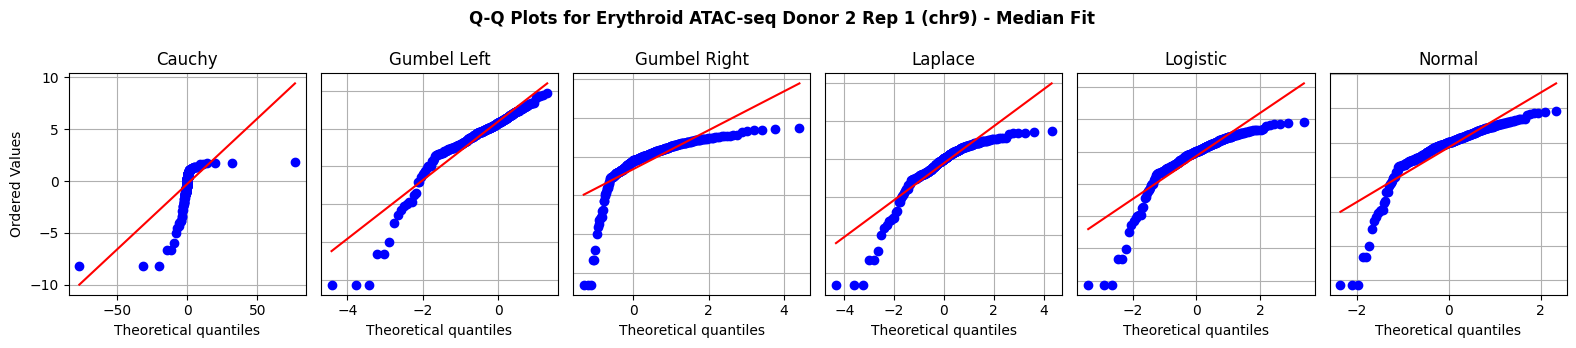

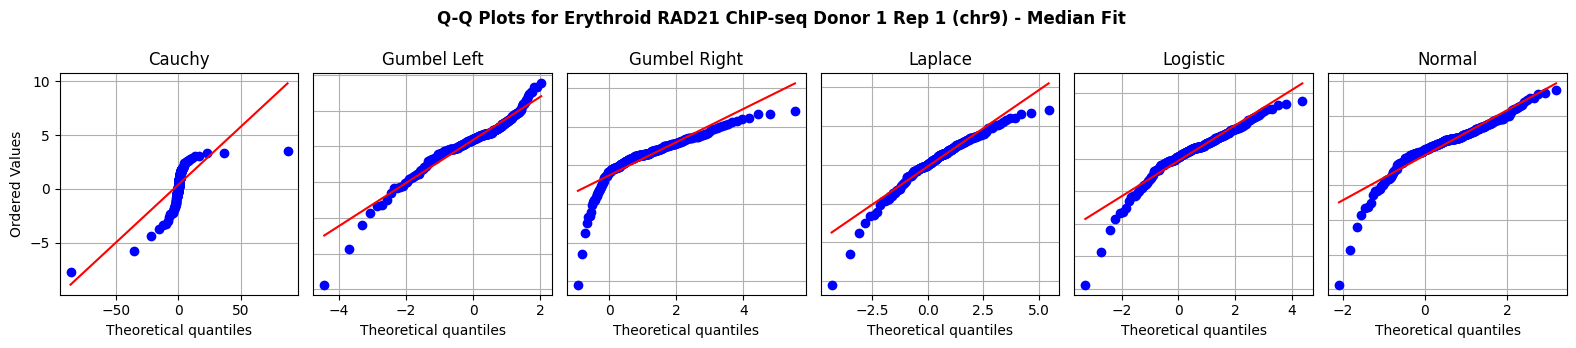

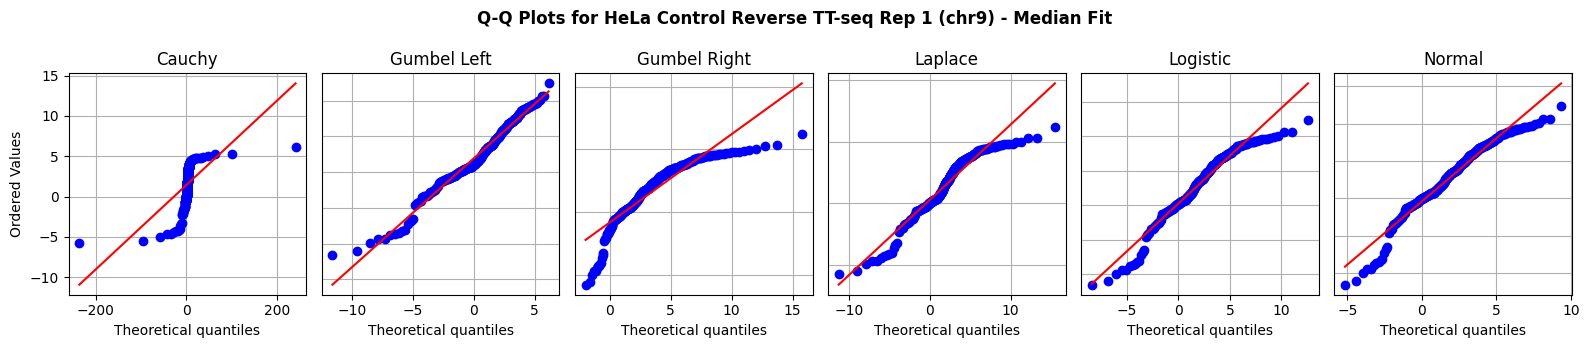

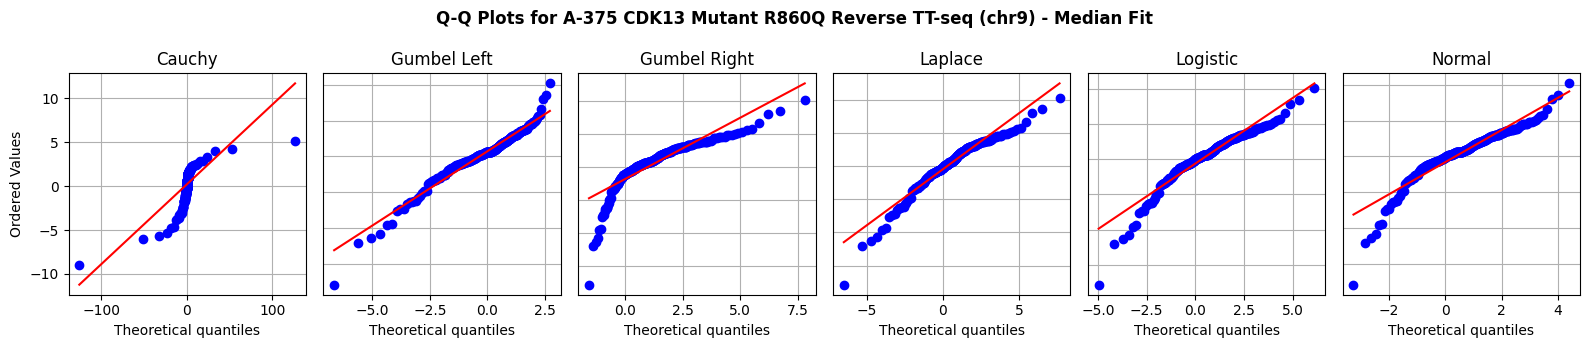

In [10]:
# Set datasets to plot and configurations (sample name, chromosome, distributions and custom sample name for title)
plot_samples = {"Erythroid_ATAC": {"sample": "GSM9320314_Don002_ATAC_d13_rep1",
                                   "chrom": "chr9",
                                   "dists": all_distributions,
                                   "custom_sample_name": "Erythroid ATAC-seq Donor 2 Rep 1"},
                "Erythroid_RAD21": {"sample": "Don001_RAD21_d13_rep1",
                                    "chrom": "chr9",
                                    "dists": all_distributions,
                                    "custom_sample_name": "Erythroid RAD21 ChIP-seq Donor 1 Rep 1"},
                "HeLa_TTseq": {"sample": "HeLa_TTseq_Control_Rep1_Neg",
                               "chrom": "chr9",
                               "dists": ["normal", "gumbel_l", "gumbel_r"],
                               "custom_sample_name": "HeLa Control Reverse TT-seq Rep 1"},
                "A375_TTseq": {"sample": "A375_TTseq_CDK13_R860Q_Rep1_Neg",
                               "chrom": "chr9",
                               "dists": all_distributions,
                               "custom_sample_name": "A-375 CDK13 Mutant R860Q Reverse TT-seq"}}

for data in plot_samples:
    # Set dataset parameters for plotting
    sample_name = plot_samples[data]["sample"]
    chrom = plot_samples[data]["chrom"]
    plot_dists = plot_samples[data]["dists"]
    bigwigs = test_bigwigs[data]

    if "custom_sample_name" in plot_samples[data]:
        custom_sample_name = plot_samples[data]["custom_sample_name"]
    else:
        custom_sample_name = sample_name

    # Create ZoneNorm object for plotting
    znorm = ZoneNorm(analysis_name = data,
                     bigwig_paths = bigwigs,
                     test_distributions = all_distributions,
                     n_cores = cores,
                     norm_method = "ZEN",
                     verbose = 0)

    znorm.plotQQPlot(plot_sample = sample_name,
                     chromosome = chrom,
                     param_type = "median_fit",
                     plot_width = 16,
                     plot_height = 3.5,
                     title = f"Q-Q Plots for {custom_sample_name} ({chrom}) - Median Fit",
                     pdf_name = f"{sample_name}_QQ_Plots")

### 4.3) Distribution Fit Plots <a id="dist-fit-plots"></a>

Create histograms of signal log-transformed signal with fitted distributions per dataset. 
* $ln(\lambda_{c})$ is the log-transformed zone threshold $ln(\lambda_{c})$, i.e. the point from which the initial threshold to separate enriched signal from background is derived.

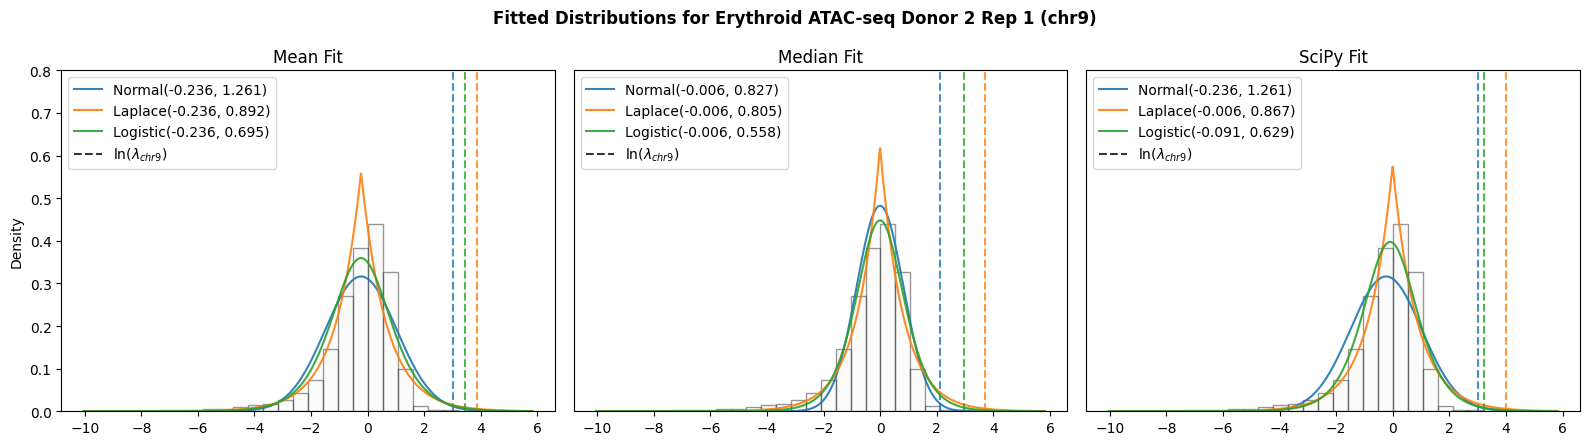

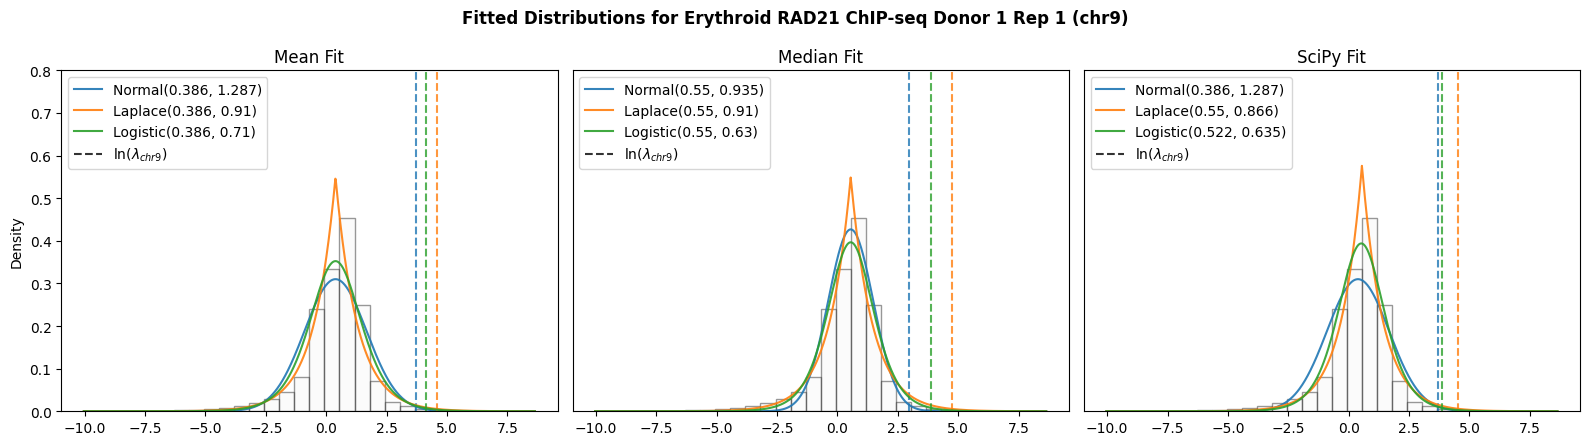

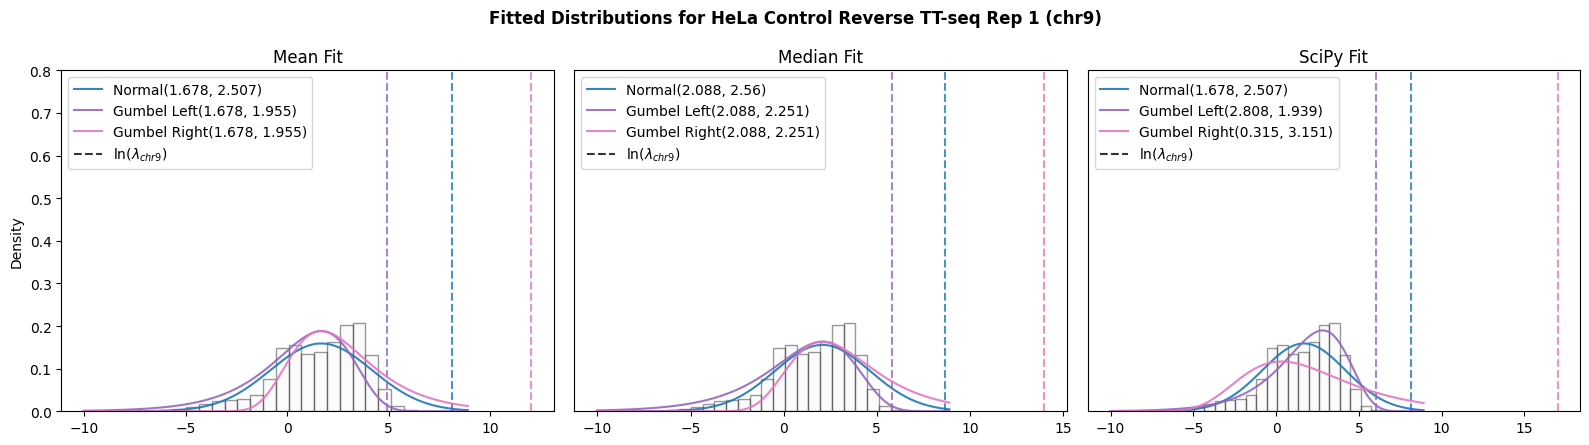

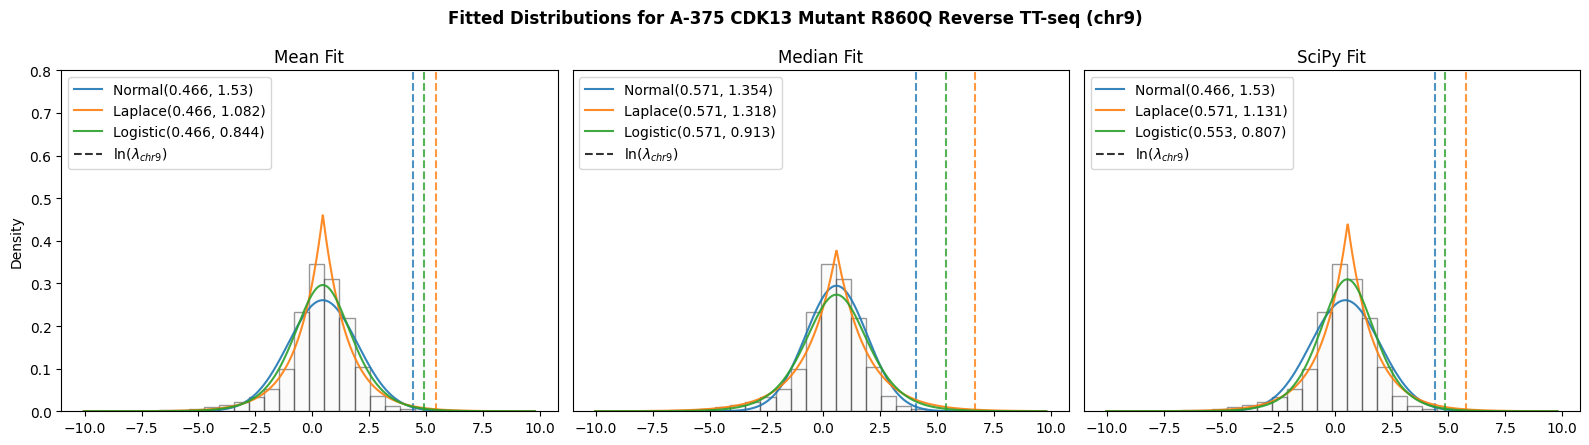

In [ ]:
# Set datasets to plot and configurations (sample name, chromosome, distributions and custom sample name for title)
plot_samples = {"Erythroid_ATAC": {"sample": "GSM9320314_Don002_ATAC_d13_rep1",
                                   "chrom": "chr9",
                                   "dists": ["normal", "laplace", "logistic"],
                                   "custom_sample_name": "Erythroid ATAC-seq Donor 2 Rep 1"},
                "Erythroid_RAD21": {"sample": "Don001_RAD21_d13_rep1",
                                    "chrom": "chr9",
                                    "dists": ["normal", "laplace", "logistic"],
                                    "custom_sample_name": "Erythroid RAD21 ChIP-seq Donor 1 Rep 1"},
                "HeLa_TTseq": {"sample": "HeLa_TTseq_Control_Rep1_Neg",
                               "chrom": "chr9",
                               "dists": ["normal", "gumbel_l", "gumbel_r"],
                               "custom_sample_name": "HeLa Control Reverse TT-seq Rep 1"},
                "A375_TTseq": {"sample": "A375_TTseq_CDK13_R860Q_Rep1_Neg",
                               "chrom": "chr9",
                               "dists": ["normal", "laplace", "logistic"],
                               "custom_sample_name": "A-375 CDK13 Mutant R860Q Reverse TT-seq"}}

for data in plot_samples:
    # Set dataset parameters for plotting
    sample_name = plot_samples[data]["sample"]
    chrom = plot_samples[data]["chrom"]
    plot_dists = plot_samples[data]["dists"]
    bigwigs = test_bigwigs[data]

    if "custom_sample_name" in plot_samples[data]:
        custom_sample_name = plot_samples[data]["custom_sample_name"]
    else:
        custom_sample_name = sample_name

    # Create ZoneNorm object for plotting
    znorm = ZoneNorm(analysis_name = data,
                     bigwig_paths = bigwigs,
                     test_distributions = all_distributions,
                     n_cores = cores,
                     norm_method = "ZEN",
                     verbose = 0)
    
    # Create distribution fitting histogram plots per sample
    znorm.plotDistributionFit(plot_sample = sample_name,
                              chromosome = chrom,
                              plot_distributions = plot_dists,
                              plot_param_types = ["mean_fit", "median_fit", "scipy_fit"],
                              y_limits = [0, 0.8],
                              plot_width = 16,
                              plot_height = 4.5,
                              title = f"Fitted Distributions for {custom_sample_name} ({chrom})",
                              pdf_name = f"{sample_name}_Histograms_{chrom}")

### 4.4) Kolmogorov-Smirnov Test Boxplots <a id="ks-boxplots"></a>

For each assay, create a mean Kolmogorov-Smirnov box plot for each distribution with parameters $(L_{c}$, $V_{c})$.

In [5]:
# Set box colours
colour_palette = ["#419BE6", "#FF8800", "#52C942"]

def KSBoxplot(results_df, colour_palette, title = "KS Statistic per Distribution", output_pdf = ""):
    """ Create boxplot of Kolmogorov-Smirnov test statistic of distribution goodness-of-fit """
    
    # Create boxplot
    plt.figure(figsize = (7, 7))
    sns.boxplot(data = results_df.sort_values(by = ["distribution", "fit"], ascending = [True, False]), 
                x = "distribution", y = "value", hue = "fit", palette = sns.color_palette(colour_palette, len(colour_palette)))

    plt.title(title, fontweight = "bold", fontsize = 14)
    plt.xlabel("Distribution", fontsize = 15)
    plt.ylabel(r"KS Stat ($D_\delta$)", fontsize = 15)
    plt.xticks(rotation = 45, fontsize = 14)
    plt.yticks(fontsize = 14)
    sns.despine(top = True, right = True, left = False, bottom = False)
    plt.legend(title = "", bbox_to_anchor = (1, 1), loc = "upper right", title_fontsize = 14, fontsize = 14, frameon = False)
    plt.tight_layout()

    # Save to PDF
    if output_pdf:
        plt.savefig(output_pdf, format = "pdf", bbox_inches = "tight")

    # Show the plot
    plt.show()

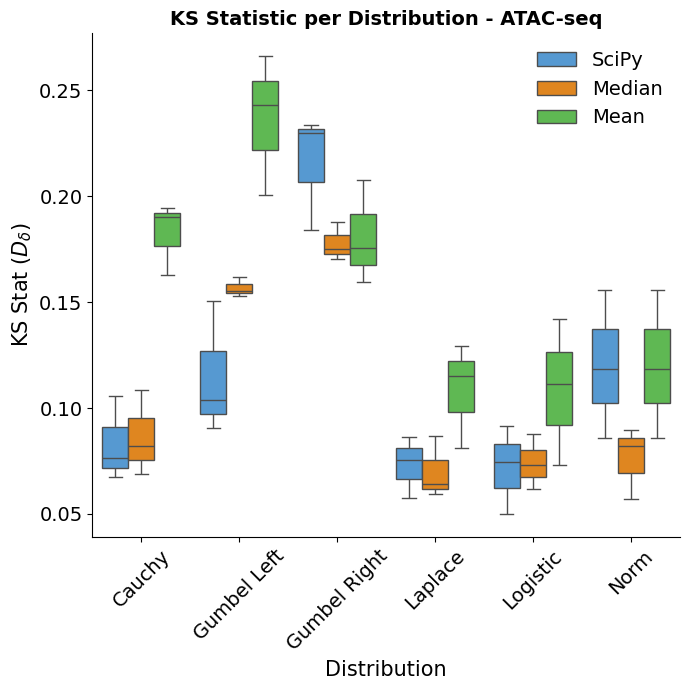

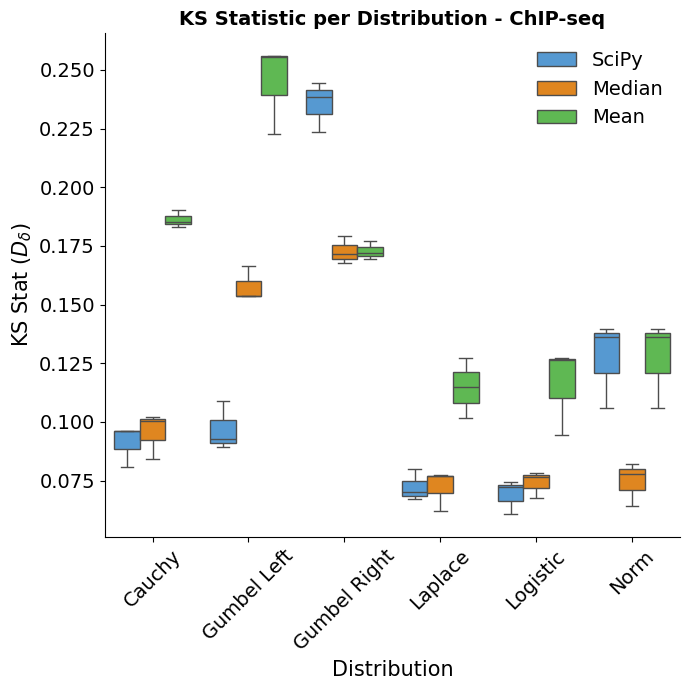

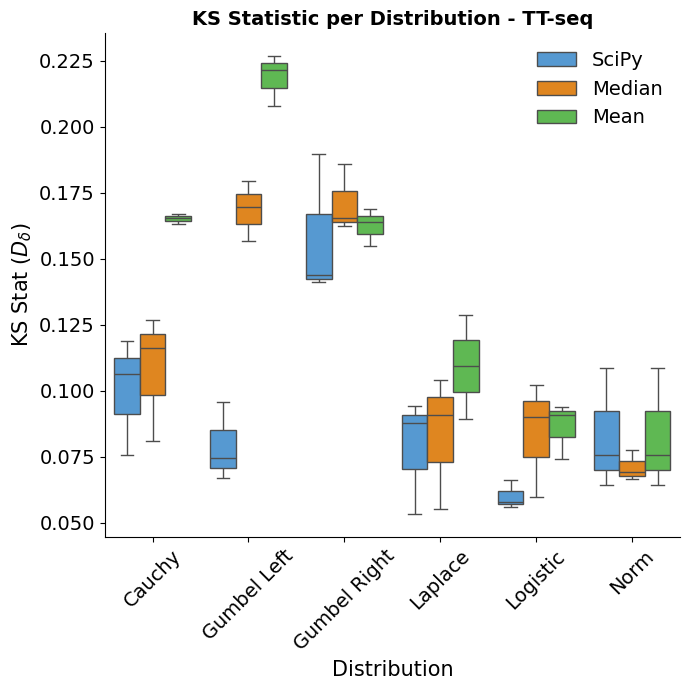

In [13]:
# Group datasets by experiment type
assay_types = {"ATAC-seq": ["Erythroid_ATAC", "H1_ATAC", "CATlas_scATAC"],
               "ChIP-seq": ["Erythroid_RAD21", "Erythroid_CTCF", "HEL_Pol2"],
               "TT-seq": ["HeLa_TTseq", "HEK293T_TTseq", "A375_TTseq"]}

# Calculate average Kolmogorov-Smirnov statistics per dataset
for assay in assay_types:
    dataset_names = []
    distributions = []
    param_types = []
    ks_stats = []
        
    for data in assay_types[assay]:
        bigwigs = test_bigwigs[data]
        znorm = ZoneNorm(analysis_name = data,
                         bigwig_paths = bigwigs,
                         test_distributions = all_distributions,
                         n_cores = cores,
                         norm_method = "ZEN",
                         verbose = 0)

        # Get the average statistics for the dataset
        dist_stats = znorm.getStats("distribution")[["distribution", "param_type", "KS_stat"]]
        # Add values to lists
        dataset_names.extend([znorm.getAnalysisName()] * len(dist_stats))
        distributions.extend(dist_stats["distribution"].to_list())
        param_types.extend(dist_stats["param_type"].to_list())
        ks_stats.extend(dist_stats["KS_stat"].to_list())

    for i in range(len(dataset_names)):
        # Convert names to title case
        distributions[i] = distributions[i].title().replace("_L", " Left").replace("_R", " Right")
        param_types[i] = param_types[i].title().replace("_Fit", "").replace("Scipy", "SciPy")

    # Create DataFrame for the assay
    ks_df = pd.DataFrame({"dataset": dataset_names,
                          "distribution": distributions,
                          "fit": param_types,
                          "value": ks_stats})

    # Calculate average KS
    ks_mean_df = ks_df.groupby(["dataset", "distribution", "fit"], as_index = False)["value"].mean()

    # Create the box plot
    KSBoxplot(results_df = ks_mean_df, colour_palette = colour_palette, 
              title = f"KS Statistic per Distribution - {assay}", output_pdf = f"KS_Boxplot_{assay}.pdf")

## 5) Testing Other ZEN Parameters <a id="parameter-tests"></a>

Though ZEN was designed to generalise across datasets and assays, performance can be improved by dataset-specific parameter tuning. Here performance is measured via genome-wide alignment using Wasserstein distances ($w$).

### 5.1) Running ZEN With Custom Parameter Configurations

Run ZEN across datasets using the default parameters and additional runs where exactly one parameter at a time is varied from its default including:
* Triangular smoothing kernel $\kappa_{n}$ with size $101 \leq n \leq 501$
* Down-sampling to $100 \leq \delta \leq 1,000$ values and no down-sampling during distribution fitting
* Zone probability $0.9 \leq p \leq 0.999$
* Minimum region size $10 \leq r \leq 100$
* Minimum region difference $1 \leq m \leq 100$
* Normalising from padded zones with padding bin size $100 \leq b \leq 2,000$ or from unpadded zones

In [ ]:
# Set the bigWigs of ATAC-seq, ChIP-seq and TT-seq to run parameter tests for
test_bigwigs = {"Erythroid_ATAC": "Example_Data/Erythroid_ATAC/BigWigs",
                "Erythroid_RAD21": "Example_Data/Erythroid_RAD21/BigWigs",
                "HeLa_TTseq": "Example_Data/HeLa_TTseq/BigWigs",
                "HEK293T_TTseq": "Example_Data/HEK293T_TTseq/BigWigs"}

# Set the parameter names and values to test
test_params = {"Kernel": [101, 201, 301, 401, 501], # Smoothing kernel (convolution)
               "Downsample": [100, 200, 300, 400, 500, 1000, None], # Downsample size (distribution fitting)
               "Prob": [0.9, 0.99, 0.995, 0.999], # Zone probability (zone prediction)
               "Region": [10, 20, 35, 50, 100], # Minimum region bps (zone prediction)
               "Diff": [1, 5, 10, 20, 50, 100], # Minimum different bps in region (zone prediction)
               "Bin": [None, 100, 250, 500, 750, 1000, 2000]} # Bin size (zone prediction)

# Set IDs for variants of ZEN with different values for the parameter
norm_method_ids = {}

for param in test_params:
    # Set identifiers for variants of ZEN with different values for the parameter
    norm_method_ids[param] = [f"ZEN_{param}_{i}".replace(".", "") for i in test_params[param]]

# Specify IDs for ZEN's default parameters to avoid recreating the same results multiple times
zen_defaults = {"Kernel": "ZEN_Kernel_301",
                "Downsample": "ZEN_Downsample_300",
                "Prob": "ZEN_Prob_0995",
                "Bin": "ZEN_Bin_1000",
                "Region": "ZEN_Region_35",
                "Diff": "ZEN_Diff_5"}

In [ ]:
# Ensure version with default parameters only run once
created_default = False

# Run ZEN per dataset with each variant of the parameters (other than default)
for data in test_bigwigs:
    bigwigs = test_bigwigs[data]

    for param in test_params:
        name = data.replace("_", " ")
        print(f"Testing {param} for {name}")

        # Default parameters
        kernel = ZoneNorm.createTriangleKernel(size = 301)
        downsample_size = 300
        zone_probability = 0.995
        bin_size = 1000
        zen_padded_zones = True
        min_region_bps = 35
        min_different_bps = 5

        # Test ZEN with different values for each parameter
        for i in test_params[param]:
            norm_id = f"{data}_{param}_{i}"
            analysis_name = norm_id

            if norm_id == zen_defaults[param]:
                if created_default:
                    # Skip creating results multiple times for the default parameter
                    continue
                else:
                    created_default = True
                    analysis_name = data

            if param == "Kernel":
                kernel = ZoneNorm.createTriangleKernel(size = i)

            elif param == "Downsample":
                downsample_size = i

            elif param == "Prob":
                zone_probability = i

            elif param == "Bin":
                if i is None:
                    zen_padded_zones = False
                else:
                    bin_size = i
                    zen_padded_zones = True

            elif param == "Region":
                min_region_bps = i
            else:
                min_different_bps = i

            znorm = ZoneNorm(analysis_name = analysis_name,
                             bigwig_paths = bigwigs,
                             norm_method = "ZEN",
                             kernel = kernel,
                             downsample_size = downsample_size,
                             zone_probability = zone_probability,
                             bin_size = bin_size,
                             zen_padded_zones = zen_padded_zones,
                             min_region_bps = min_region_bps,
                             min_different_bps = min_different_bps,
                             n_cores = cores,
                             verbose = 1)

            # Create smoothed signal
            znorm.convolveSignals()
            # Test Laplace distribution
            znorm.testDistributions()
            # Use distribution to predict signal zone coordinates
            znorm.predictSignalZones()
            # Create normalised bigWigs
            znorm.normaliseSignal()

### 5.2) Measure Genome-Wide Alignment by Wasserstein Distance

After running ZEN across different parameter configurations, genome-wide alignment can be measured by calculating mix-max scaled Wasserstein distance ($w$) between all replicates. For punctate assays, ATAC-seq and ChIP-seq, LanceOtron peaks are used. For TT-seq padded zones are used to represent regions of transcription.
* This can take a while to run.

In [7]:
# Set LanceOtron peak calls for ATAC-seq and ChIP-seq
peak_dirs = {"Erythroid_ATAC": "Example_Data/Erythroid_ATAC/LanceOtron_Peaks",
             "Erythroid_RAD21": "Example_Data/Erythroid_RAD21/LanceOtron_Peaks"}

In [19]:
# Create dataframes setting the normalised bigWigs to compare and the regions (peaks or zones) to compare them across 
bw_dfs = {}
regions_dfs = {}

for data in test_bigwigs:
    bw_dfs[data] = {}
    regions_dfs[data] = {}

    for param in test_params:
        # Create zonenorm object to extract sample names
        znorm = ZoneNorm(analysis_name = data,
                         bigwig_paths = test_bigwigs[data],
                         verbose = 0)
        
        sample_names = znorm.getSampleNames()
        norm_ids = norm_method_ids[param]
        n_samples = len(sample_names)
        n_norm = len(norm_ids)

        bigwigs = []

        for i in norm_ids:
            for s in sample_names:
                bigwigs.append(os.path.join(os.getcwd(), f"{data}_{i}", "Results", "BigWigs", "ZEN", f"{s}_ZEN.bw"))

        # Create bigWigs CSV
        bw_dfs[data][param] = pd.DataFrame({"norm": np.repeat(norm_ids, n_samples),
                                            "sample": np.tile(sample_names, n_norm),
                                            "bigwig": bigwigs})

        if data in peak_dirs:
            # Create regions CSV using the peak calls per sample
            regions_dfs[data][param] = CompareNorm.createRegionsFileCSV(sample_names = sample_names,
                                                                        regions_directory = peak_dirs[data],
                                                                        file_postfix = "_L-tron",
                                                                        file_extension = ".bed",
                                                                        csv_file = "")
        else:
            # Create regions CSV using the padded signal zones per sample
            regions_dfs[data][param] = CompareNorm.createRegionsFileCSV(sample_names = sample_names, 
                                                                        regions_directory = os.path.join(data, "Results", "BED", "Zones"),
                                                                        file_prefix = "padded_zones_",
                                                                        file_extension = ".bed")

In [ ]:
for data in test_bigwigs:
    for param in test_params:
        # Specify input bigWigs, peaks and parameters for normalisation method comparision
        compare_norm = CompareNorm(analysis_name = f"{data}_{param}",
                                   bigwig_df = bw_dfs[data][param],
                                   regions_df = regions_dfs[data][param],
                                   min_peak_score = 0.5,
                                   min_consensus = 1,
                                   n_cores = cores)
        # Calculate Wasserstein distances
        compare_norm.plotWasserstein(norm_methods = norm_method_ids[param],
                                     reference_norm = "ZEN",
                                     star_test = "linear",
                                     use_fdr = True,
                                     pdf_name = f"{data}_{param}_Wasserstein_Plot")

### 5.3) Plot Effects of Changing ZEN Parameters on Alignment

After calculating $w$ between replicates for each parameter configuration, averages are compared to find those with the strongest alignment (lowest $w$). Below, mean $w$ is plotted per dataset, where the results for ZEN with default parameters are shown by hollow black circles.

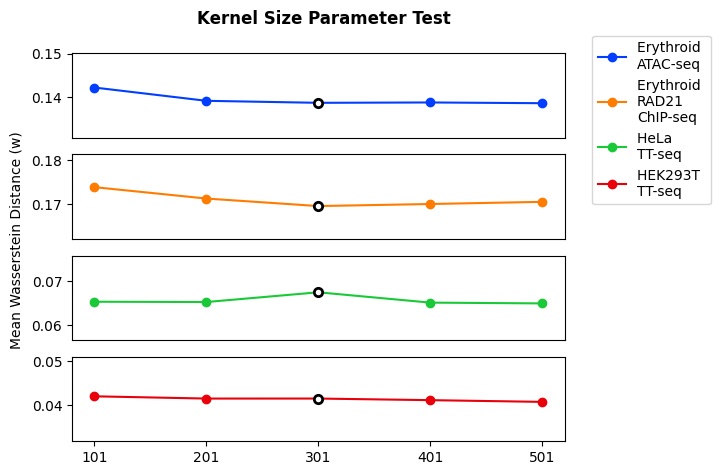

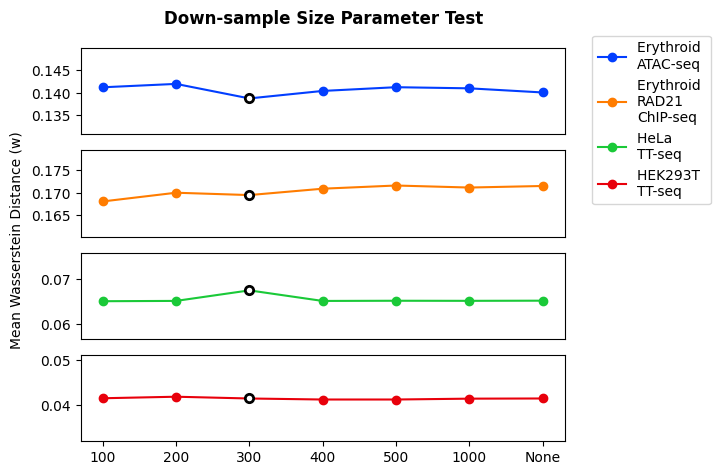

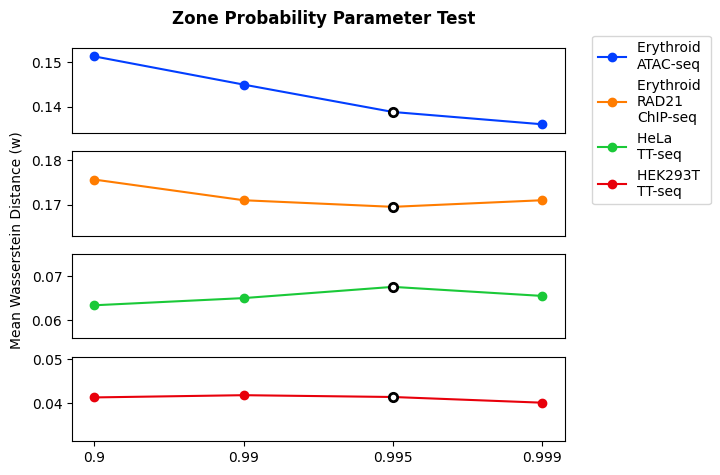

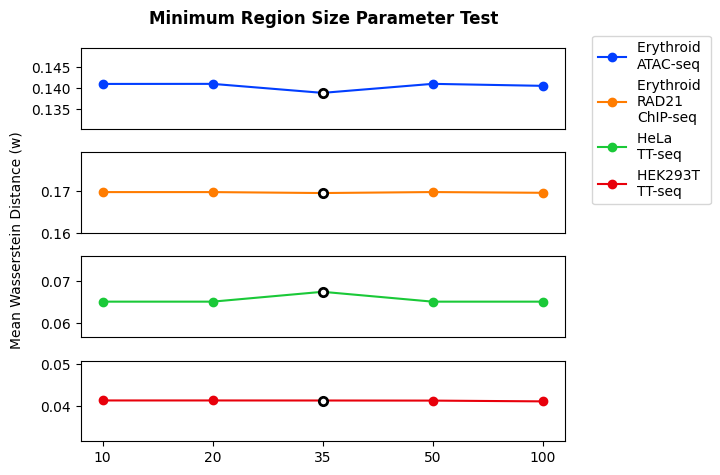

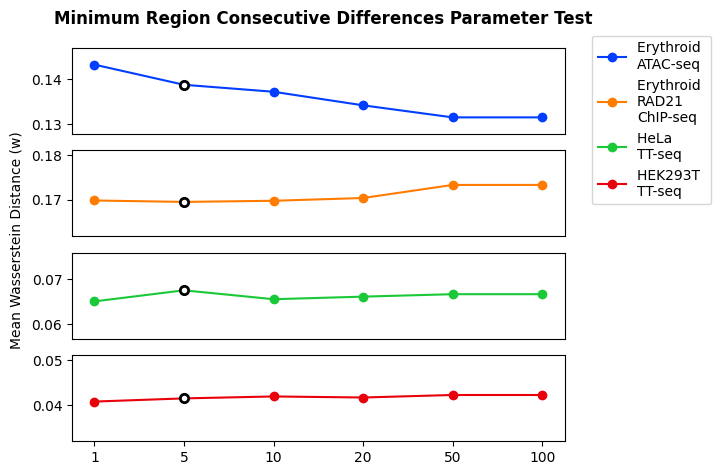

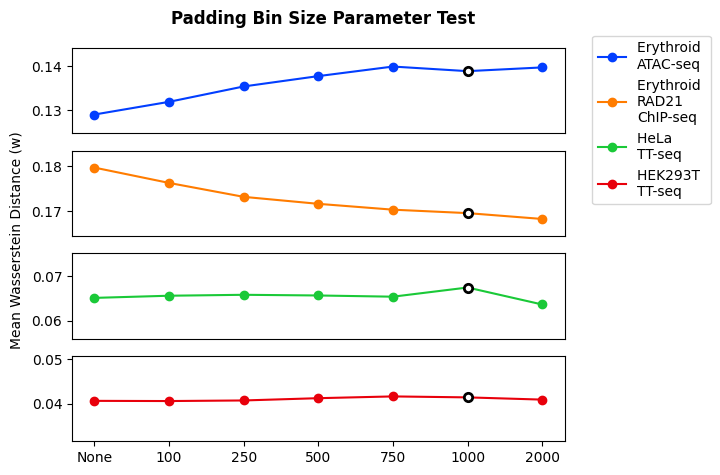

In [22]:
n_datasets = len(test_bigwigs)
trace_colours = np.array(list(color_palette("bright", n_datasets).as_hex()))

param_plots = {}
y_ranges = {}
y_centers = {}

for param in test_params:
    if param == "Kernel":
        param_name = "Kernel Size (n)"
    elif param == "Downsample":
        param_name = "Down-sample Size (δ)"
    elif param == "Prob":
        param_name = "Zone Probability (p)"
    elif param == "Region":
        param_name = "Minimum Region Size (r)"
    elif param == "Diff":
        param_name = "Minimum Region Consecutive Differences (m)"
    elif param == "Bin":
        param_name = "Padding Bin Size (b)"
    else:
        param_name = param

    y_ranges[param] = np.zeros(n_datasets)
    y_centers[param] = np.zeros(n_datasets)

    # Create sub-plot per dataset
    fig, axes = plt.subplots(n_datasets, sharex = True)

    for i in range(n_datasets):
        data = list(test_bigwigs.keys())[i]
        ax = axes[i]
        name = data.replace("_", " ")
        name = name.replace("TTseq", "\nTT-seq")
        name = name.replace("ATAC", "\nATAC-seq")
        name = name.replace("RAD21", "\nRAD21\nChIP-seq")
        name = name.replace("-seqseq", "seq")
        colour = trace_colours[i]

        try:
            dist_df = pd.read_csv(f"{data}_{param}/Results/Stats/wasserstein_distances.csv")
        except:
            print(f"Missing Wasserstein distances for {name} {param_name}")
            continue

        all_norm_methods = [f"ZEN_{param}_{j}".replace(".", "") for j in test_params[param]]
        
        # Calculate mean wasserstein distance per normalisation method
        average_dists = dist_df.groupby("norm_method")["wasserstein_distance"].mean()
        average_dists = average_dists.rename(index = {"ZEN": zen_defaults[param]})
        average_dists = average_dists.reindex(all_norm_methods).values

        # Set the x-axis labels and y-axis values
        x_values = [str(i) for i in test_params[param]]
        y_values = average_dists

        # Record the range of the values
        min_y = min(y_values)
        max_y = max(y_values)
        y_ranges[param][i] = max_y - min_y
        y_centers[param][i] = (min_y + max_y) / 2

        #print(data, param, x_values[np.where(y_values == min_y)[0][0]])

        # Add values to the sub-plot
        ax.plot(x_values, y_values, marker = "o", label = name, color = colour)

        # Highlight the default parameter as a different colour
        default_idx = np.where(np.array(norm_method_ids[param]) == zen_defaults[param].replace(".", ""))[0][0]

        ax.plot(x_values[default_idx], y_values[default_idx], marker = "o",
                markersize = 6, markeredgewidth = 2, markerfacecolor = "white", 
                markeredgecolor = "black", zorder = 5)

    plt.suptitle(f"{param_name[:-4]} Parameter Test", fontweight = "bold")
    #plt.xlabel(param_name)
    plt.xlabel("")
    fig.text(0.01, 0.5, "Mean Wasserstein Distance (w)", rotation = "vertical", va = "center")
    fig.legend(loc = "center left", bbox_to_anchor = (0.92, 0.75), borderaxespad = 0)

    # Record the figure for further configuration
    figure = {}
    figure["fig"] = fig
    figure["axes"] = axes
    param_plots[param] = figure

plt.tight_layout()

max_range = np.ceil(np.max(np.array(list(y_ranges.values()))) * 1000) / 1000
half_max_range = (max_range / 2) + (0.1 * max_range)

for test in test_params:
    fig = param_plots[test]["fig"]
    axes = param_plots[test]["axes"]
    
    # Set the y-axis range as a comparible scale across all plots
    for i in range(n_datasets):
        if y_ranges[test][i] != 0:
            ax = axes[i]
            center_value = y_centers[test][i]
            ax.set_ylim(center_value - half_max_range, center_value + half_max_range)

    # Hide x-axis ticks for all except last sub-plots
    for ax in axes[:-1]:
        ax.tick_params(axis = "x", which = "both", bottom = False, labelbottom = False)

    fig.tight_layout(rect = [0.02, 0, 0.9, 1])
    fig.savefig(f"{test}_Parameter_Test.pdf", format = "pdf", bbox_inches = "tight", pad_inches = 0.02)

plt.show()